<a href="https://colab.research.google.com/github/phongsitt9/motor-glm-pricing/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 📊 Notebook 02 — Exploratory Data Analysis (EDA)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df = pd.read_csv("clean_data.csv")

/tmp/ipykernel_11188/1174201362.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


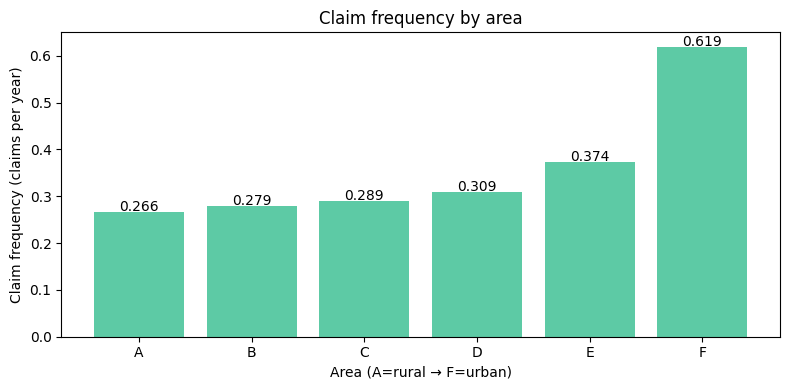


💡 Insight: urban areas (E,F) tend to have higher claim frequency


In [10]:
area_stats = (df.groupby("Area")
               .apply(lambda x: pd.Series({
                   "ClaimFrequency": x["ClaimNb"].sum() / x["Exposure"].sum(),
                   "PolicyCount":    len(x)
               })).reset_index())
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(area_stats["Area"], area_stats["ClaimFrequency"], color="#5DCAA5")
ax.set_xlabel("Area (A=rural → F=urban)")
ax.set_ylabel("Claim frequency (claims per year)")
ax.set_title("Claim frequency by area")
for bar, val in zip(bars, area_stats["ClaimFrequency"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", fontsize=10)
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig("outputs/freq_by_area.png", dpi=150)
plt.show()
print("\n💡 Insight: urban areas (E,F) tend to have higher claim frequency")

/tmp/ipykernel_11188/3770265232.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


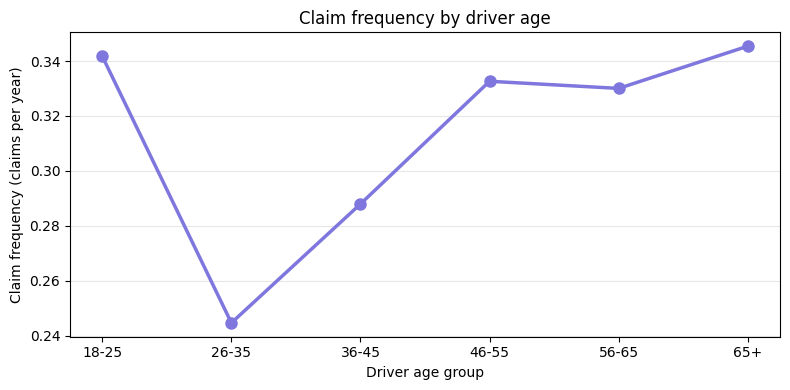


💡 Insight: young drivers (18-25) have significantly higher frequency


In [12]:
df["AgeGroup"] = pd.cut(df["DrivAge"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])

age_stats = (df.groupby("AgeGroup", observed=True)
               .apply(lambda x: pd.Series({
                   "ClaimFrequency": x["ClaimNb"].sum() / x["Exposure"].sum()
               })).reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(age_stats["AgeGroup"], age_stats["ClaimFrequency"],
        marker="o", color="#7F77DD", linewidth=2.5, markersize=8)
ax.set_xlabel("Driver age group")
ax.set_ylabel("Claim frequency (claims per year)")
ax.set_title("Claim frequency by driver age")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/freq_by_drivage.png", dpi=150)
plt.show()
print("\n💡 Insight: young drivers (18-25) have significantly higher frequency")

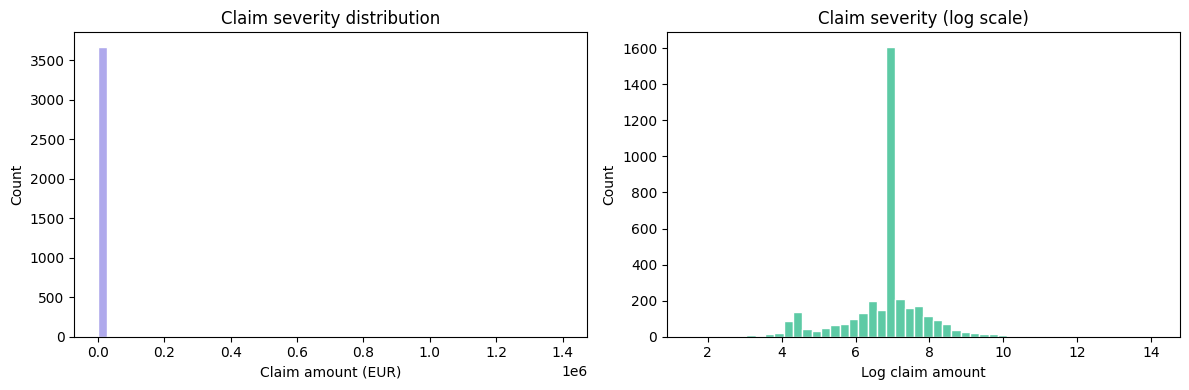


💡 Mean severity: EUR 2,314
   Median severity: EUR 1,128


In [13]:
claims_only = df[df["ClaimAmount"] > 0]["ClaimAmount"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(claims_only, bins=50, color="#AFA9EC", edgecolor="white")
axes[0].set_title("Claim severity distribution")
axes[0].set_xlabel("Claim amount (EUR)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log(claims_only), bins=50, color="#5DCAA5", edgecolor="white")
axes[1].set_title("Claim severity (log scale)")
axes[1].set_xlabel("Log claim amount")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("outputs/severity_dist.png", dpi=150)
plt.show()
print(f"\n💡 Mean severity: EUR {claims_only.mean():,.0f}")
print(f"   Median severity: EUR {claims_only.median():,.0f}")

/tmp/ipykernel_11188/281323200.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bm_stats = (df.groupby(pd.cut(df["BonusMalus"], bins=10))


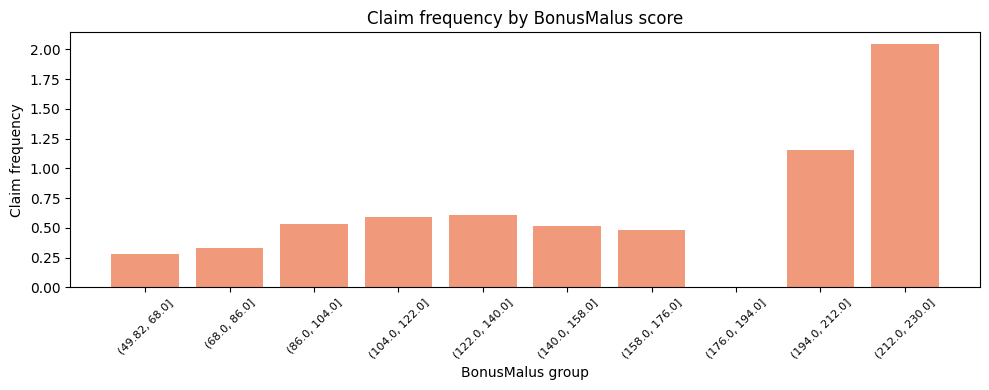


💡 Higher BonusMalus = worse driving history = higher frequency


In [14]:
bm_stats = (df.groupby(pd.cut(df["BonusMalus"], bins=10))
              .apply(lambda x: pd.Series({
                  "ClaimFrequency": x["ClaimNb"].sum() / x["Exposure"].sum()
              })).reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(bm_stats)), bm_stats["ClaimFrequency"], color="#F0997B")
ax.set_xticks(range(len(bm_stats)))
ax.set_xticklabels([str(i) for i in bm_stats["BonusMalus"]], rotation=45, fontsize=8)
ax.set_xlabel("BonusMalus group")
ax.set_ylabel("Claim frequency")
ax.set_title("Claim frequency by BonusMalus score")
plt.tight_layout()
plt.savefig("outputs/freq_by_bonusmalus.png", dpi=150)
plt.show()
print("\n💡 Higher BonusMalus = worse driving history = higher frequency")

In [15]:
summary = pd.DataFrame({
    "Metric": [
        "Total policies",
        "Total claims",
        "Overall claim frequency",
        "Mean claim severity (EUR)",
        "Total losses (EUR)",
        "Mean pure premium (EUR)"
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['ClaimNb'].sum():,}",
        f"{df['ClaimNb'].sum() / df['Exposure'].sum():.4f}",
        f"{df[df['ClaimAmount']>0]['ClaimAmount'].mean():,.0f}",
        f"{df['ClaimAmount'].sum():,.0f}",
        f"{df['PurePremium'].mean():,.2f}"
    ]
})

display(summary)
summary.to_csv("outputs/eda_summary.csv", index=False)
print("✅ EDA complete — ready for Notebook 03")

,Metric,Value
0,Total policies,"73,735"
1,Total claims,"13,485.0"
2,Overall claim frequency,0.3054
3,Mean claim severity (EUR),"2,314"
4,Total losses (EUR),"8,546,965"
5,Mean pure premium (EUR),670.03


✅ EDA complete — ready for Notebook 03
